In [11]:
import sys
import os
import math
import glob
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS, 
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.layers import QuantizedLayerMixin

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Sym_INT8", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [ ]:
def _fix_quantization_dtypes(module, method='symmetric', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    """
    Universal-Loader für Baseline UND Quantisierte Modelle.
    """
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    
    if quant_config:
        print(f"Repariere Quantisierung ({quant_config})...")
        method = quant_config.get('method', 'symmetric')
        bits = quant_config.get('bits', 8)

        for name, module in model.named_modules():
            # Wir prüfen duck-typing oder Klasse
            if hasattr(module, "quant_mode") or isinstance(module, QuantizedLayerMixin):
             _fix_quantization_dtypes(module, method, bits)
    else:
        print(" Baseline Modus (Float32).")
        if hasattr(model, 'convert_to_baseline'):
            model.convert_to_baseline()
            
    model.eval()
    return model

In [ ]:
def get_all_predictions(model, data_loader):
    """
    Führt Inferenz auf dem gesamten Loader durch und gibt rohe Listen/Arrays zurück.
    Kein Plotting hier! Nur Datenverarbeitung.
    """
    model.eval()
    all_preds = []
    all_targets = []

    sample_images = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            data = data.to(DEVICE)

            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()

            all_preds.extend(pred)
            all_targets.extend(target.numpy())

            if i == 0:
                sample_images = data.cpu()
            
    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [ ]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        name_q = class_names[p_quant] if class_names else str(p_quant)
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

✅ Baseline Modus (Float32).
Repariere Quantisierung ({'method': 'symmetric', 'bits': 8})...

📊 --- Performance: Baseline Float32 ---
Accuracy:   0.7529 (75.29%)
Error Rate: 0.2471 (24.71%)
----------------------------------------
              precision    recall  f1-score   support

           0     0.7778    0.7778    0.7778         9
           1     0.7000    0.7000    0.7000        10
           2     0.4545    1.0000    0.6250         5
           3     1.0000    0.1111    0.2000         9
           4     0.6250    1.0000    0.7692         5
           5     0.9000    0.7500    0.8182        12
           6     0.5833    1.0000    0.7368         7
           7     0.7778    1.0000    0.8750         7
           8     1.0000    0.8000    0.8889        10
           9     0.3750    1.0000    0.5455         3
          10     1.0000    1.0000    1.0000         6
          11     0.8000    1.0000    0.8889         4
          12     0.0000    0.0000    0.0000         1
          13 

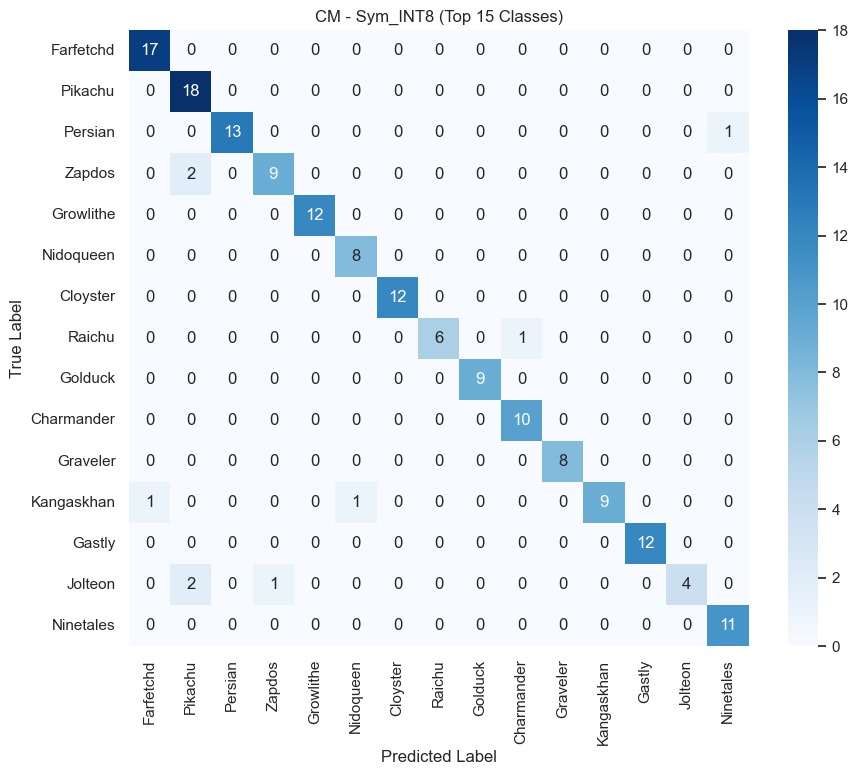

🎨 Visualisiere 50 Beispiele...


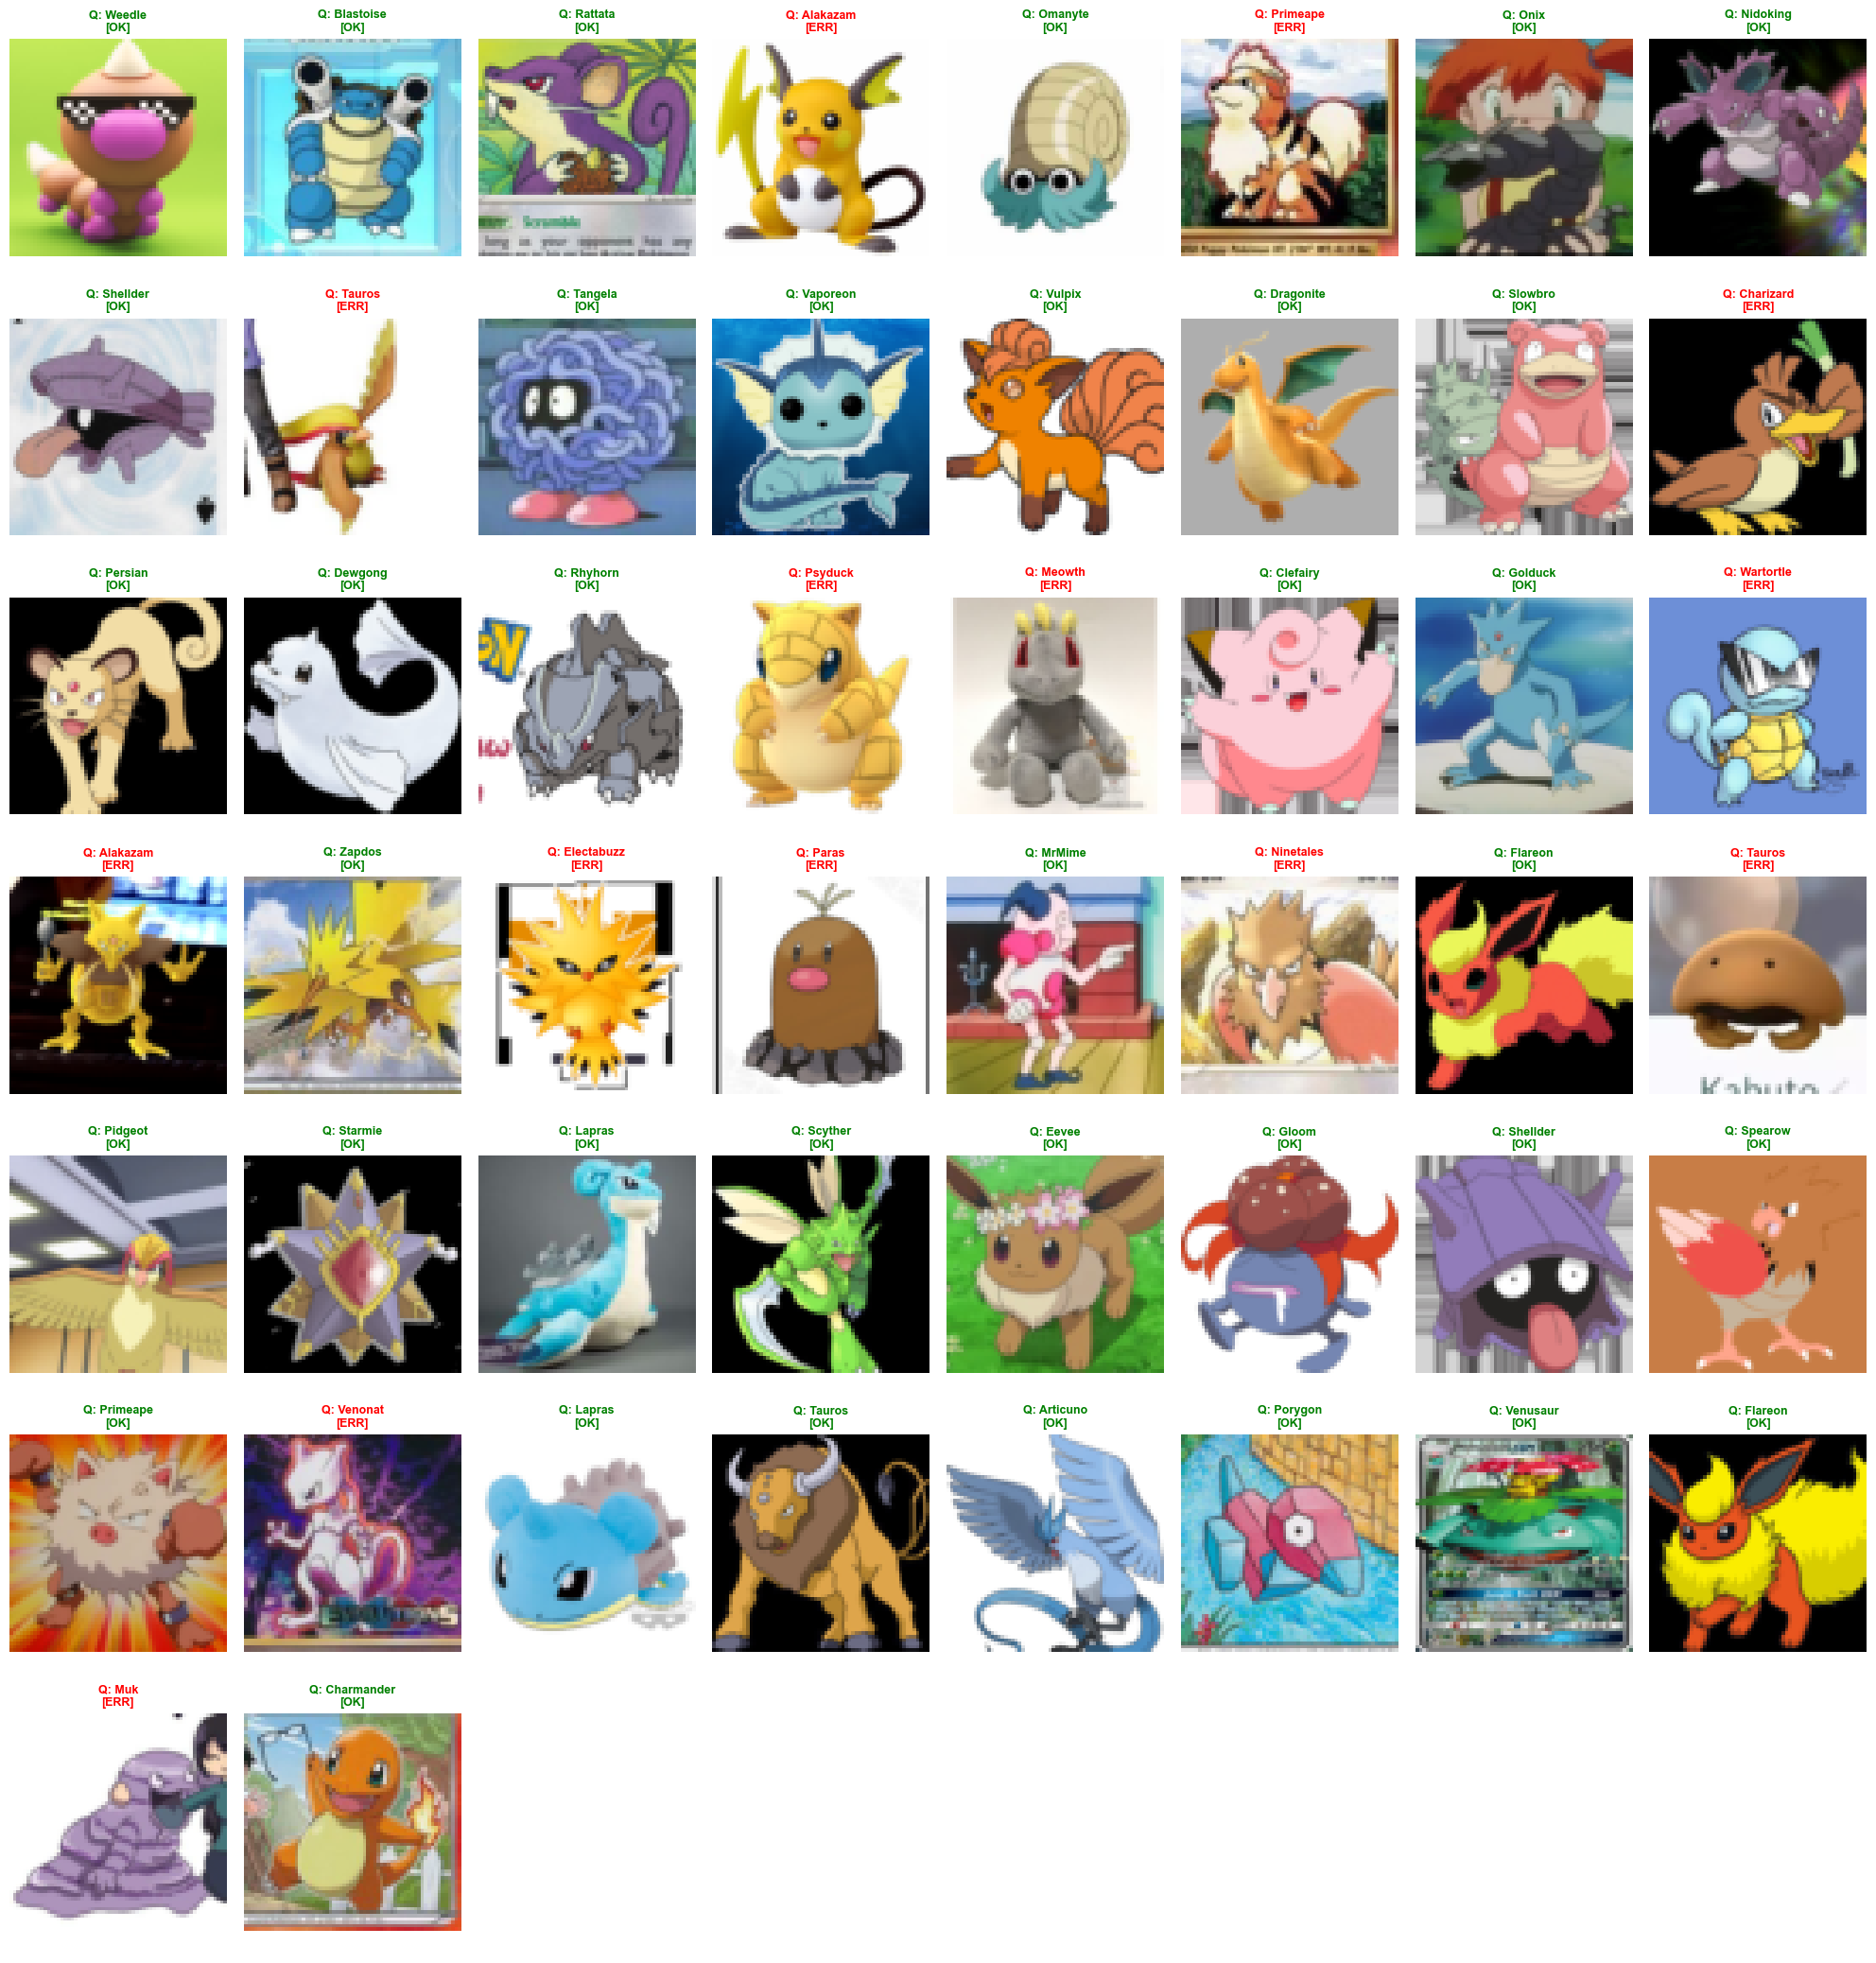

Analysiere Gewichtsverteilung der Baseline...


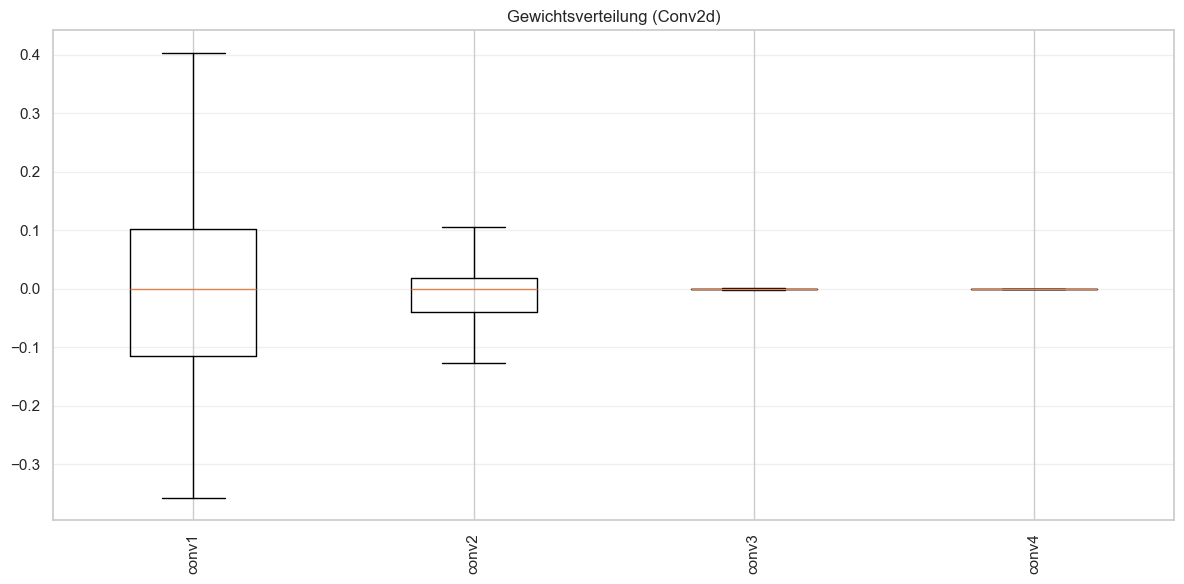

In [15]:
train_loader, test_loader, num_classes = get_data_loaders()
# Versuche Klassennamen zu finden
class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

# 2. Config ableiten (Automatisch aus dem Namen)
q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Affine' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8

# 3. Modelle laden
# A) Baseline
baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])

# B) Quantized
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model = load_model(
    CNN, 
    num_classes, 
    q_path, 
    quant_config={'method': q_method, 'bits': q_bits}
)

# 4. Inferenz & Metriken
res_base = get_all_predictions(baseline_model, test_loader)
res_quant = get_all_predictions(quantized_model, test_loader)

print_metrics(res_base, "Baseline Float32")
print_metrics(res_quant, f"Quantized {q_name}")

# 5. Visualisierung
# A) Verwirrungsmatrix (Vergleich)
plot_confusion_matrix(res_quant['targets'], res_quant['preds'], class_names, title=f"CM - {q_name}")

# B) Visueller Vergleich (Bilder)
# Wir nutzen die 'sample_images' aus dem Baseline-Result (da identisch)
# und nehmen die ersten N Predictions aus den Gesamt-Ergebnissen
plot_visual_comparison(
    res_base['sample_images'], 
    res_base['preds'][:len(res_base['sample_images'])], 
    res_quant['preds'][:len(res_base['sample_images'])], 
    res_base['targets'][:len(res_base['sample_images'])],
    class_names,
    num_samples=CONFIG['vis_samples']
)

# C) Gewichts-Analyse (Optional)
print("Analysiere Gewichtsverteilung der Baseline...")
plot_weight_distribution(baseline_model)